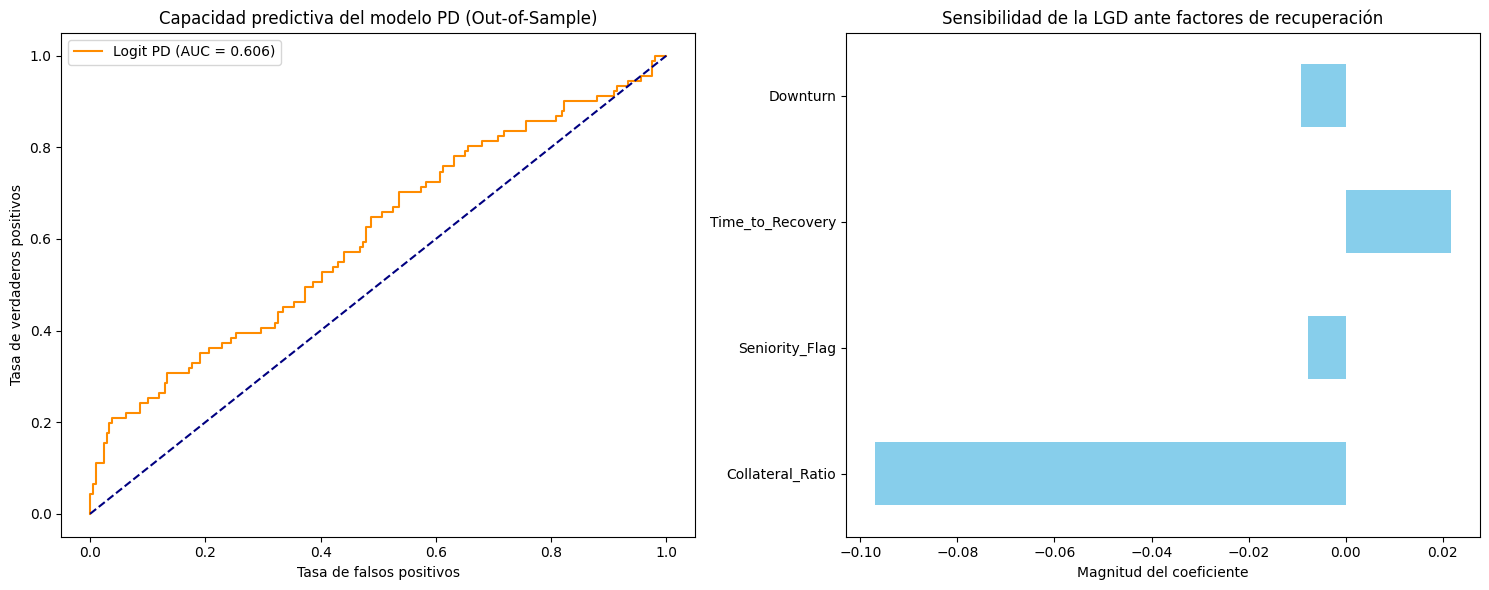


RESUMEN DE MÉTRICAS
Gini (PD): 0.211
RMSE (LGD): 0.3358


In [2]:
#PROYECTO: Credit_Risk_Modeling
#Elaborado por: Ricardo Alexis Sifuentes Zevallos
#Objetivo: Estimación de PD (Logit) y LGD (Regresión Lineal) con validación OOS

!pip install -q pandas numpy matplotlib scikit-learn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import roc_auc_score, roc_curve, mean_squared_error

#MODELAMIENTO DE PROBABILIDAD DE DEFAULT (PD)

#Carga de datos German Credit (OpenML)
data_pd = fetch_openml('credit-g', version=1, as_frame=True)
df_pd = data_pd.frame.copy()

#Preprocesamiento: Variable objetivo (1: Bad/Default, 0: Good)
df_pd['default'] = (df_pd['class'] == 'bad').astype(int)

#Selección de variables numéricas explicativas
X_pd = df_pd.select_dtypes(include=['int64', 'float64']).drop(columns=['default'])
y_pd = df_pd['default']

#Split y escalamiento
X_train_pd, X_test_pd, y_train_pd, y_test_pd = train_test_split(X_pd, y_pd, test_size=0.3, random_state=42)
scaler_pd = StandardScaler()
X_train_pd_s = scaler_pd.fit_transform(X_train_pd)
X_test_pd_s = scaler_pd.transform(X_test_pd)

#Modelo Logit
logit = LogisticRegression()
logit.fit(X_train_pd_s, y_train_pd)

#Evaluación PD (AUC)
probs_test_pd = logit.predict_proba(X_test_pd_s)[:, 1]
auc_pd = roc_auc_score(y_test_pd, probs_test_pd)

#MODELAMIENTO DE PÉRDIDA DADO EL INCUMPLIMIENTO (LGD)

#Carga de datos LGD desde archivo (Archivo excel en la misma carpeta)
try:
    df_lgd = pd.read_excel("LGD_Recovery_Realistic.xlsx")

    #Feature engineering: LGD = 1 - Recovery Rate
    df_lgd["LGD"] = 1 - df_lgd["Recovery_Rate"]
    df_lgd["Collateral_Ratio"] = df_lgd["Collateral_Value"] / df_lgd["Exposure"]
    df_lgd["Seniority_Flag"] = (df_lgd["Seniority"] == "Senior").astype(int)

    #Variables explicativas
    X_lgd = df_lgd[["Collateral_Ratio", "Seniority_Flag", "Time_to_Recovery", "Downturn"]]
    y_lgd = df_lgd["LGD"]

    #Split y Escalamiento
    X_train_lgd, X_test_lgd, y_train_lgd, y_test_lgd = train_test_split(X_lgd, y_lgd, test_size=0.3, random_state=1402)
    scaler_lgd = StandardScaler()
    X_train_lgd_s = scaler_lgd.fit_transform(X_train_lgd)
    X_test_lgd_s = scaler_lgd.transform(X_test_lgd)

    #Modelo Benchmark (Regresión lineal)
    model_lgd = LinearRegression()
    model_lgd.fit(X_train_lgd_s, y_train_lgd)

    #Evaluación LGD (RMSE)
    lgd_pred = model_lgd.predict(X_test_lgd_s)
    rmse_lgd = np.sqrt(mean_squared_error(y_test_lgd, lgd_pred))

except FileNotFoundError:
    print("Archivo 'LGD_Recovery_Realistic.xlsx' no encontrado. Saltando.")
    rmse_lgd = None

#VISUALIZACIÓN INTEGRADA

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

#Gráfico 1: Curva ROC (PD)
fpr, tpr, _ = roc_curve(y_test_pd, probs_test_pd)
ax[0].plot(fpr, tpr, label=f'Logit PD (AUC = {auc_pd:.3f})', color='darkorange')
ax[0].plot([0, 1], [0, 1], linestyle='--', color='navy')
ax[0].set_title('Capacidad predictiva del modelo PD (Out-of-Sample)')
ax[0].set_xlabel('Tasa de falsos positivos')
ax[0].set_ylabel('Tasa de verdaderos positivos')
ax[0].legend()

#Gráfico 2: Importancia de variables (LGD - Coeficientes)
if 'model_lgd' in locals():
    coefs = pd.Series(model_lgd.coef_, index=X_lgd.columns)
    coefs.plot(kind='barh', ax=ax[1], color='skyblue')
    ax[1].set_title('Sensibilidad de la LGD ante factores de recuperación')
    ax[1].set_xlabel('Magnitud del coeficiente')

plt.tight_layout()
plt.show()

#Resumen
print("\n" + "="*40)
print("RESUMEN DE MÉTRICAS")
print(f"Gini (PD): {2*auc_pd - 1:.3f}")
if rmse_lgd: print(f"RMSE (LGD): {rmse_lgd:.4f}")
print("="*40)